In [1]:
import pandas as pd

In [2]:
dataset=pd.read_csv("PrePlacement.csv")

In [3]:
dataset.isnull().sum()

sl_no             0
gender            0
ssc_p             0
ssc_b             0
hsc_p             0
hsc_b             0
hsc_s             0
degree_p          0
degree_t          0
workex            0
etest_p           0
specialisation    0
mba_p             0
status            0
salary            0
dtype: int64

In [4]:
quan=[]
qual=[]
for columnName in dataset.columns:
    if(dataset[columnName].dtype=='str'):
        qual.append(columnName)
    else:
        quan.append(columnName)

In [5]:
print(quan)

['sl_no', 'ssc_p', 'hsc_p', 'degree_p', 'etest_p', 'mba_p', 'salary']


In [6]:
dataset[quan].cov()

,sl_no,ssc_p,hsc_p,degree_p,etest_p,mba_p,salary
sl_no,3870.000000,-52.641355,-58.106028,-40.413645,52.556168,8.102336,2.449065e+04
ssc_p,-52.641355,117.228377,60.348373,42.897137,37.659225,24.535952,9.017549e+05
hsc_p,-58.106028,60.348373,118.755706,34.819820,35.461678,22.555846,7.633598e+05
degree_p,-40.413645,42.897137,34.819820,54.151103,21.929469,17.272020,4.651315e+05
etest_p,52.556168,37.659225,35.461678,21.929469,176.251018,16.886973,3.842344e+05
mba_p,8.102336,24.535952,22.555846,17.272020,16.886973,34.028376,1.262455e+05
salary,24490.654206,901754.893936,763359.777657,465131.504238,384234.419257,126245.485547,2.395714e+10


In [7]:
dataset[quan].corr()

,sl_no,ssc_p,hsc_p,degree_p,etest_p,mba_p,salary
sl_no,1.000000,-0.078155,-0.085711,-0.088281,0.063636,0.022327,0.002543
ssc_p,-0.078155,1.000000,0.511472,0.538404,0.261993,0.388478,0.538090
hsc_p,-0.085711,0.511472,1.000000,0.434206,0.245113,0.354823,0.452569
degree_p,-0.088281,0.538404,0.434206,1.000000,0.224470,0.402364,0.408371
etest_p,0.063636,0.261993,0.245113,0.224470,1.000000,0.218055,0.186988
mba_p,0.022327,0.388478,0.354823,0.402364,0.218055,1.000000,0.139823
salary,0.002543,0.538090,0.452569,0.408371,0.186988,0.139823,1.000000


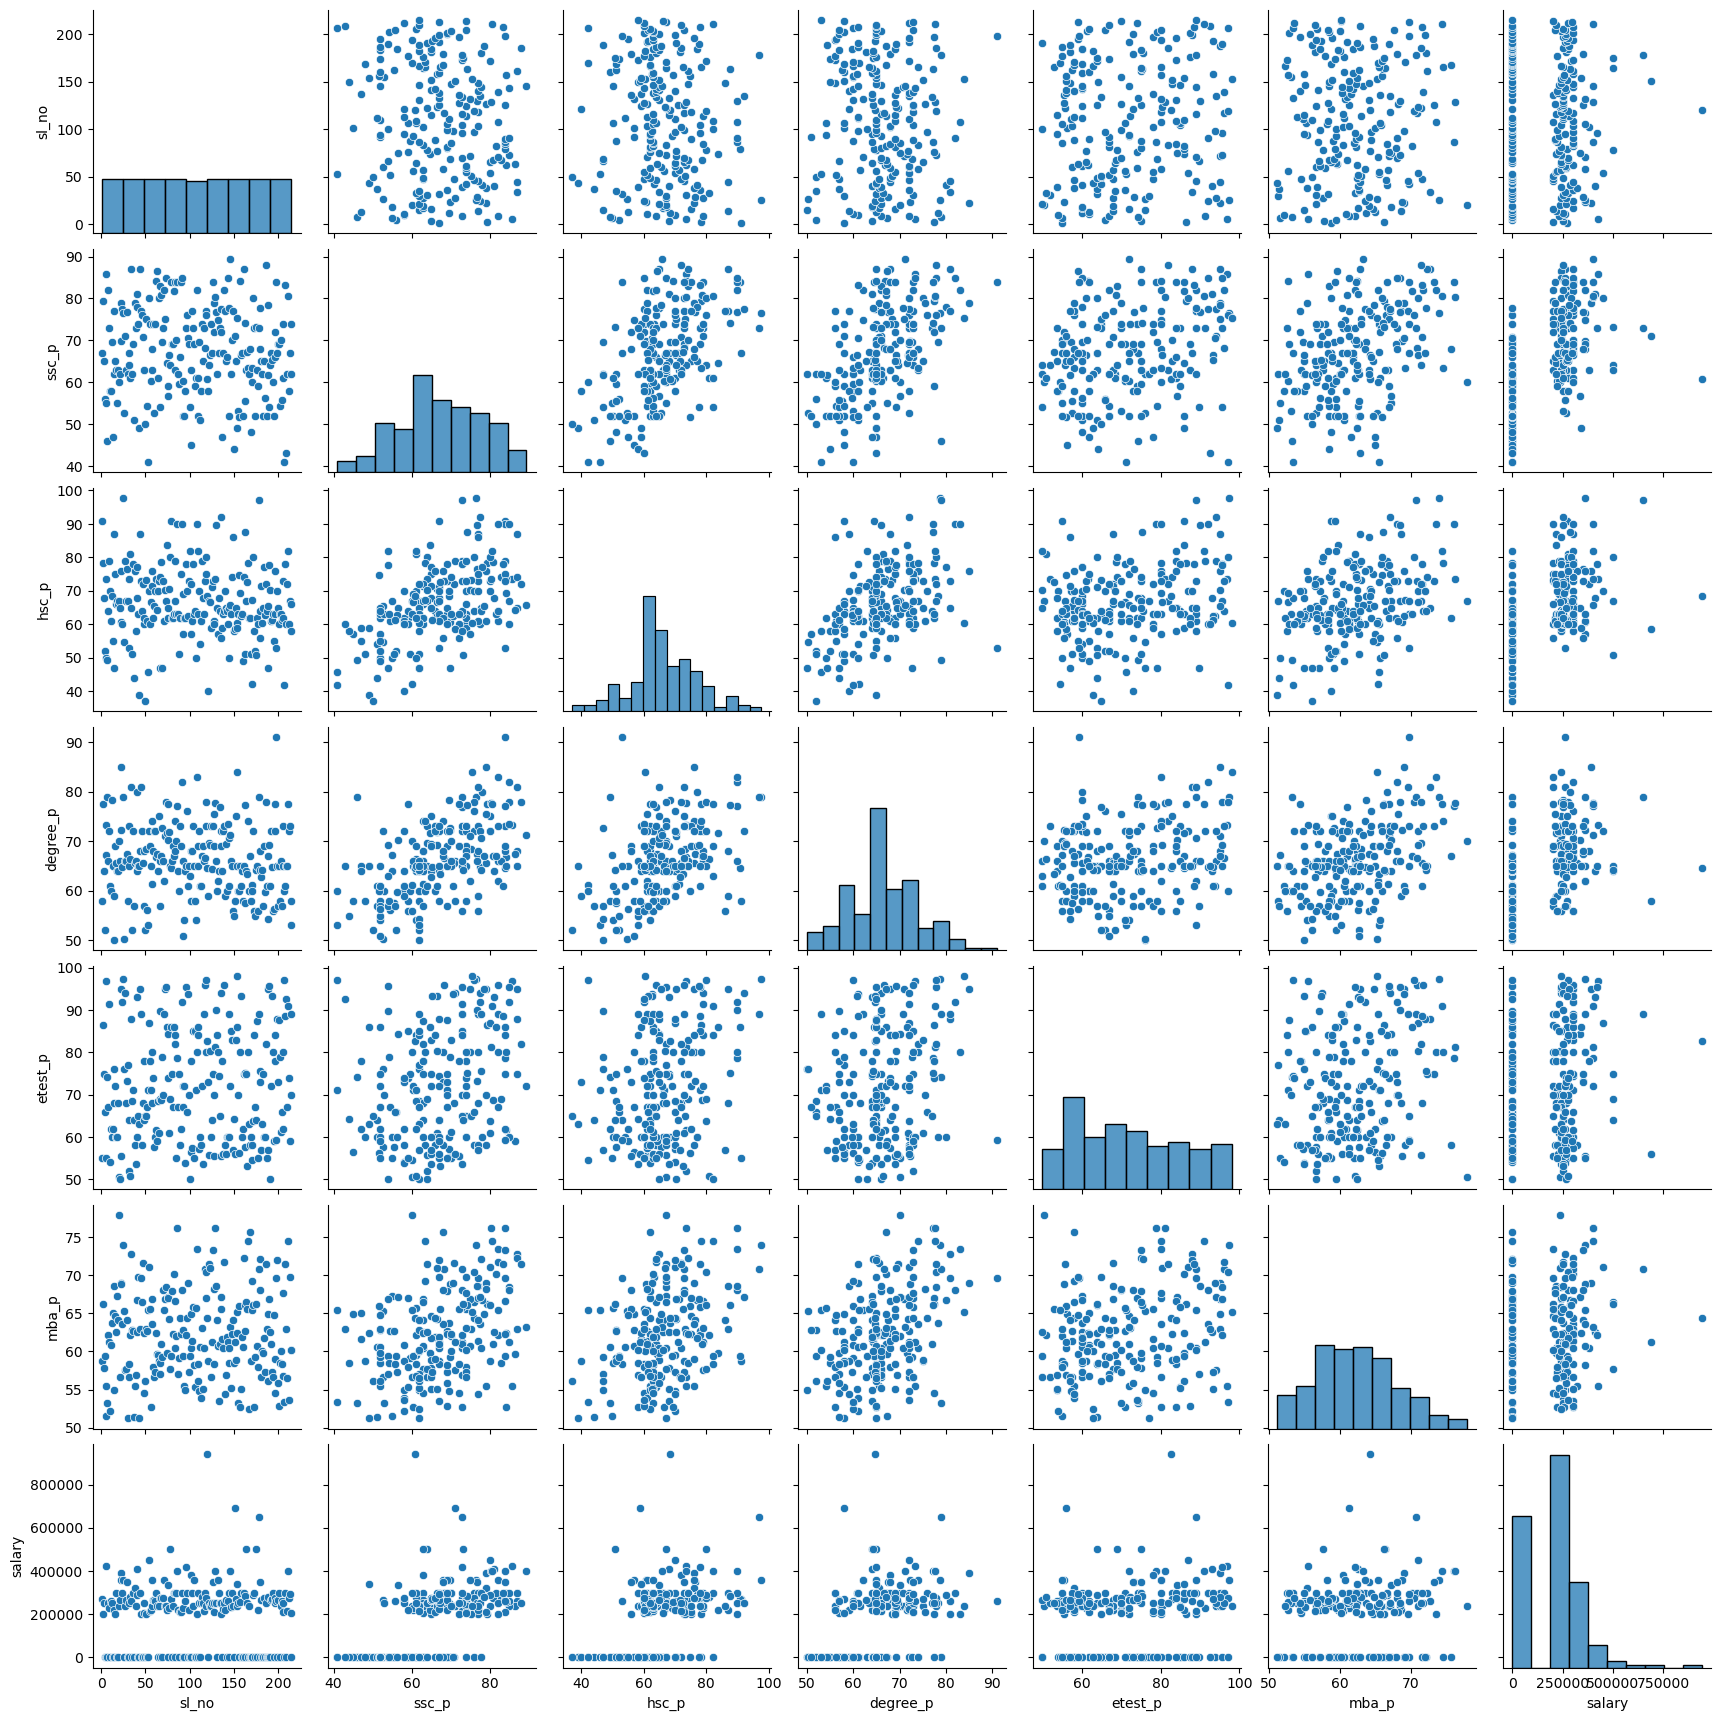

In [8]:
import seaborn as sns
sns.pairplot(dataset)

In [9]:
!pip install statsmodels 

In [10]:
def calc_vif(x):
    from statsmodels.stats.outliers_influence import variance_inflation_factor
    vif=pd.DataFrame()
    vif["Variables"]=x.columns
    vif["VIF"]=[variance_inflation_factor(x.values,i) for i in range(x.shape[1])]
    return vif

In [11]:
calc_vif(dataset[quan])

,Variables,VIF
0,sl_no,4.046145
1,ssc_p,76.789794
2,hsc_p,59.219135
3,degree_p,113.326503
4,etest_p,33.191651
5,mba_p,118.651958
6,salary,3.939976


In [12]:
quan.remove("mba_p")
calc_vif(dataset[quan])

,Variables,VIF
0,sl_no,3.888394
1,ssc_p,71.653628
2,hsc_p,54.757319
3,degree_p,82.327873
4,etest_p,31.782180
5,salary,3.425232


In [13]:
quan.remove("degree_p")
calc_vif(dataset[quan])

,Variables,VIF
0,sl_no,3.845483
1,ssc_p,51.029623
2,hsc_p,46.223586
3,etest_p,29.066710
4,salary,3.352027


In [14]:
quan.remove("ssc_p")
calc_vif(dataset[quan])

,Variables,VIF
0,sl_no,3.834410
1,hsc_p,26.156197
2,etest_p,24.446982
3,salary,3.135479


In [15]:
quan.remove("hsc_p")
calc_vif(dataset[quan])

,Variables,VIF
0,sl_no,3.802356
1,etest_p,5.535050
2,salary,2.745283


In [ ]:
#Independent - Unpaired T test

In [23]:
from scipy.stats import ttest_ind

In [21]:
male=dataset[dataset['gender']=='M']['salary']
female=dataset[dataset['gender']=='F']['salary']
ttest_ind(male,female)

TtestResult(statistic=np.float64(2.1103433958668765), pvalue=np.float64(0.035995606467451834), df=np.float64(213.0))

In [ ]:
#Dependent - Paired T test

In [24]:
from scipy.stats import ttest_rel
male=dataset[dataset['gender']=='M']['ssc_p']
male1=dataset[dataset['gender']=='M']['hsc_p']
ttest_rel(male,male1)

TtestResult(statistic=np.float64(0.6852881050898076), pvalue=np.float64(0.494311646007315), df=np.int64(138))

In [ ]:
#Analysis of Variance

In [25]:
import scipy.stats as stats
stats.f_oneway(dataset['ssc_p'],dataset['hsc_p'],dataset['degree_p'])

F_onewayResult(statistic=np.float64(0.6719700864663096), pvalue=np.float64(0.511060281899647))

In [ ]:
#Since the p-value > 0.O5% WE ACCEPT THE NULL HYPOTHESIS
#THERE IS NO SIGNIFICANT CHANGE IN SSC_P,HSC_P AND DEGREE_P MARKS